In [10]:
import pandas as pd

data_path = "../data"

product_df = pd.read_csv(f"{data_path}/data_products_id_tiny.csv")
product_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31931 entries, 0 to 31930
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     31931 non-null  int64 
 1   image          31931 non-null  object
 2   name           31931 non-null  object
 3   shop_name      31931 non-null  object
 4   shopid         31931 non-null  int64 
 5   main_category  31931 non-null  object
 6   sub_category   31931 non-null  object
dtypes: int64(2), object(5)
memory usage: 1.7+ MB


In [11]:
product_df['description'] = ""

In [12]:
import pandas as pd
from pathlib import Path

# Path to checkpoint folder
checkpoint_dir = Path("desc_checkpoints")
checkpoint_dir.mkdir(parents=True, exist_ok=True)

# Function to read .txt content by product_id
def load_txt_description(pid):
    path = checkpoint_dir / f"{pid}.txt"
    if path.exists():
        return path.read_text(encoding="utf-8").strip()
    return pd.NA

# Map the descriptions into the DataFrame
product_df["description"] = product_df["product_id"].map(load_txt_description)

In [13]:
product_df.to_csv("../data/data_products_id_tiny_with_desc.csv", index=False)

## Data Exploration

In [14]:
product_df

,product_id,image,name,shop_name,shopid,main_category,sub_category,description
0,19941741813,9cedf3c19821e83aa88a1e2f401e4e3b,Plac Poles sepatu Bersih Cream Pemutih Shoes S...,rejeki007,519630646,Sepatu Pria,Aksesoris & Perawatan Sepatu,Plac Poles Sepatu Bersih Cream adalah solusi p...
1,8609667001,94b8c7d8fabca08490e1398864a7e3d7,Bantalan Sepatu Depan / Insole (2pcs) - PR0015,Neofelis Houseware,113260191,Sepatu Wanita,Aksesoris & Perawatan Sepatu,Bantalan Sepatu Depan / Insole (2pcs) - PR0015...
2,845133903,882bfbef267af16d4a84624d1f33a885,MKL - Saddle Shoes / Shoee Tree Catokan Sepatu...,jakartakinesio,1317599,Sepatu Pria,Aksesoris & Perawatan Sepatu,**MKL - Saddle Shoes / Shoee Tree Catokan Sepa...
3,11448295634,2d16dcd0429f2c198fd3381d17696d5b,"ANTI JAMUR TAS KULIT DAUN TALAS ANTI AIR, LEAT...",Garael Official Store,526900249,Sepatu Pria,Aksesoris & Perawatan Sepatu,"**ANTI JAMUR TAS KULIT DAUN TALAS ANTI AIR, LE..."
4,12648185204,25eac0de61c8e0f0821daf72fb37f8c6,1 Pasang Insole Pad dan T-Shape Untuk Sepatu H...,Dishdash,14226667,Sepatu Wanita,Aksesoris & Perawatan Sepatu,Bikin pakai high heels jadi lebih nyaman sehar...
...,...,...,...,...,...,...,...,...
31926,8319206783,sg-11134201-22110-94zj010rwdkv93,SPEEDS Resistance Bands Tali Pembantu Fitness ...,CAHAYASTORE888,235433701,Olahraga & Outdoor,Yoga & Pilates,<NA>
31927,18440709211,1751fd2c7a26809c474fc53ddc2fe96c,Karet Pull Up Resistance Band Fitness Gym Late...,SportMoll,446317704,Olahraga & Outdoor,Yoga & Pilates,<NA>
31928,21726848050,ddda4b7866950ad892e17b1a8f18f050,SPEEDS Resistance Band 1 Set Yoga Band Loop Ba...,Speedsstore,184942443,Olahraga & Outdoor,Yoga & Pilates,<NA>
31929,12859437106,ac1b114802405545111f57855e7e6cf4,LIGHTSPEED RESISTANCE TUBE BAND / RESISTANCE 1...,Lightspeed Official Shop,478845512,Olahraga & Outdoor,Yoga & Pilates,<NA>


In [15]:
product_df["desc_len_char"] = product_df["description"].str.len()
product_df["desc_len_word"] = product_df["description"].str.split().apply(lambda x: len(x) if isinstance(x, list) else 0)

In [16]:
print(product_df["desc_len_char"].mean())
print(product_df["desc_len_word"].mean())

865.6632272012579
39.305283267044565


In [17]:
product_df.duplicated(subset=["product_id"]).sum()

np.int64(0)

In [18]:
from collections import Counter
import re

all_words = " ".join(product_df["description"].dropna()).lower()
tokens = re.findall(r"\b\w+\b", all_words)

word_freq = Counter(tokens)
common_words = word_freq.most_common(20)
print("Most common words in descriptions:")
for word, freq in common_words:
    print(f"{word}: {freq}")

Most common words in descriptions:
dan: 50026
yang: 35197
untuk: 34711
dengan: 31853
ini: 16730
atau: 15562
cocok: 13958
mudah: 10084
dari: 9485
sekarang: 9171
di: 8848
berbagai: 8791
nyaman: 8381
dapatkan: 8303
bahan: 8024
desain: 7221
warna: 7168
berkualitas: 7149
dalam: 7053
tanpa: 6397


In [19]:
product_df["category_in_desc"] = product_df.apply(
    lambda row: str(row["main_category"]).lower() in str(row["description"]).lower(), axis=1
)
print(product_df["category_in_desc"].mean())

0.03260154708590398


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/dikaizm/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


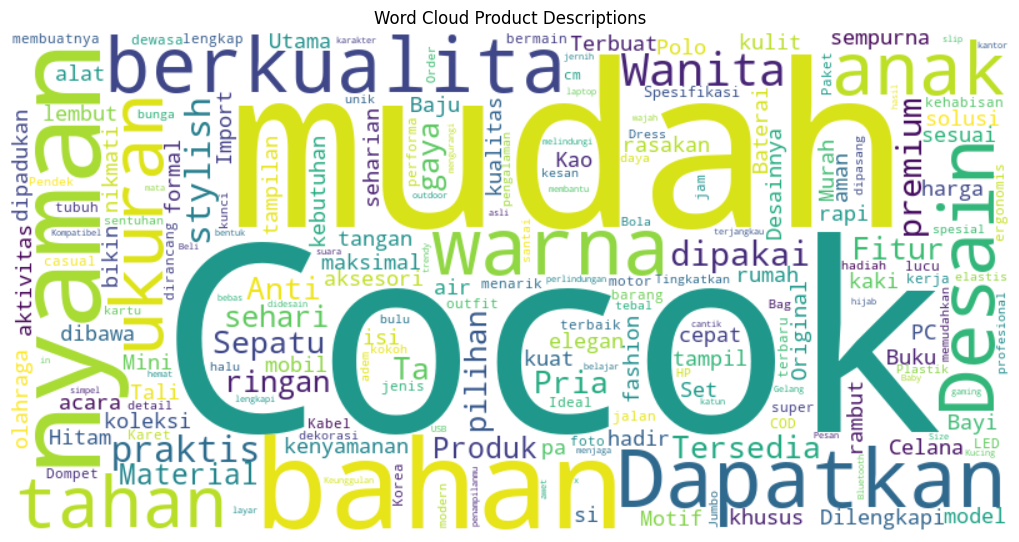

In [20]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
import nltk

nltk.download("stopwords")

product_df["combined_text"] = product_df["name"].fillna("") + " " + product_df["description"].fillna("")

all_words = " ".join(product_df["combined_text"].dropna().astype(str))

stop_words = set(stopwords.words("indonesian"))

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    stopwords=stop_words,
    max_words=200,
    collocations=False,
    contour_width=3
).generate(all_words)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud Product Descriptions")
plt.tight_layout(pad=0)
plt.show()

## Data Preprocessing

In [21]:
from sentence_transformers import SentenceTransformer
from langchain.vectorstores import FAISS
from langchain.schema import Document
from langchain.embeddings import HuggingFaceEmbeddings

# model_name = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
model_name = "Hvare/Athena-indobert-finetuned-indonli-SentenceTransformer"

# Load model
model = SentenceTransformer(model_name)

# Convert text to document list
documents = [
    Document(
        page_content = (
            f"{row['name']}. {row['description']}. "
            f"Kategori: {row['main_category']} > {row['sub_category']}."
        ),
        metadata={
            "product_id": row["product_id"],
            "name": row["name"],
            "main_category": row["main_category"],
            "sub_category": row["sub_category"],
            "shop_name": row["shop_name"]
        }
    )
    for _, row in product_df.iterrows()
    if pd.notna(row["description"])
]

# Langchain wrapper for HF model
embedding_model = HuggingFaceEmbeddings(model_name=model_name)

# create FAISS index from document
vector_store = FAISS.from_documents(documents, embedding_model)

# Save index locally
vector_store.save_local("faiss_index")

/Users/dikaizm/Documents/PROGRAMMING/machine-learning/chatbot-product-ecommerce/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/hb/b1p7kpgj4s759vkptsfqzxzw0000gn/T/ipykernel_46534/3714699838.py:32: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFaceEmbeddings``.
  embedding_model = HuggingFaceEmbeddings(model_name=model_name)


In [22]:
# Load index
vectorstore = FAISS.load_local("faiss_index", embedding_model, allow_dangerous_deserialization=True)

query = "tas sekolah anak warna cerah"

results = vectorstore.similarity_search(query, k=10)
for doc in results:
    print(doc.metadata["name"], "\n", doc.page_content, "\n")
    print("==========================\n")

Tas Selempang Anak Mini CUTIES ( ASLI IMPORT  ) mote bagus kanvas Flower Bunga motif 
 Tas Selempang Anak Mini CUTIES ( ASLI IMPORT  ) mote bagus kanvas Flower Bunga motif. Tas Selempang Anak Mini CUTIES (ASLI IMPORT) - Stylish & Lucu untuk Si Kecil!  

Bikin penampilan anak makin menggemaskan dengan Tas Selempang Mini CUTIES yang super imut ini! Dibuat dari bahan kanvas berkualitas dengan motif bunga warna-warni yang cantik, tas ini pasti jadi favorit si kecil. Desainnya yang mini dan ringan sangat pas untuk anak-anak, cocok dipakai sehari-hari atau saat jalan-jalan.  

✨ **Fitur Produk:**  
✅ Bahan kanvas premium yang awet dan nyaman  
✅ Motif bunga cerah dengan detail menggemaskan  
✅ Tali selempang adjustable (bisa diatur panjangnya)  
✅ Ukuran mini pas untuk anak-anak  
✅ Ringan & praktis untuk dibawa kemana saja  

Dapatkan sekarang juga dan lengkapi gaya fashion si kecil dengan tas selempang yang unik dan stylish! Tersedia dalam berbagai pilihan motif menarik.  

**Tas Selempang

In [23]:
# FAISS index retriever
retriever = vectorstore.as_retriever(search_type="similarity", search_kwargs={"k": 5})

query = "tas sekolah anak warna cerah"
docs = retriever.invoke(query)
for doc in docs:
    print(doc.metadata["name"], "\n", doc.page_content, "\n")
    print("==========================\n")

Tas Selempang Anak Mini CUTIES ( ASLI IMPORT  ) mote bagus kanvas Flower Bunga motif 
 Tas Selempang Anak Mini CUTIES ( ASLI IMPORT  ) mote bagus kanvas Flower Bunga motif. Tas Selempang Anak Mini CUTIES (ASLI IMPORT) - Stylish & Lucu untuk Si Kecil!  

Bikin penampilan anak makin menggemaskan dengan Tas Selempang Mini CUTIES yang super imut ini! Dibuat dari bahan kanvas berkualitas dengan motif bunga warna-warni yang cantik, tas ini pasti jadi favorit si kecil. Desainnya yang mini dan ringan sangat pas untuk anak-anak, cocok dipakai sehari-hari atau saat jalan-jalan.  

✨ **Fitur Produk:**  
✅ Bahan kanvas premium yang awet dan nyaman  
✅ Motif bunga cerah dengan detail menggemaskan  
✅ Tali selempang adjustable (bisa diatur panjangnya)  
✅ Ukuran mini pas untuk anak-anak  
✅ Ringan & praktis untuk dibawa kemana saja  

Dapatkan sekarang juga dan lengkapi gaya fashion si kecil dengan tas selempang yang unik dan stylish! Tersedia dalam berbagai pilihan motif menarik.  

**Tas Selempang

## LLM Integration

In [24]:
from langchain_google_genai import ChatGoogleGenerativeAI
import os
from dotenv import load_dotenv

load_dotenv()

api_key = os.getenv("GOOGLE_GENAI_API_KEY")

model = "gemini-2.5-flash"
llm = ChatGoogleGenerativeAI(
    model=model,
    api_key=api_key
)

In [25]:
messages = [
    ("system", "You are a helpful translator. Translate the user sentence to French."),
    ("human", "I love programming."),
]
llm.invoke(messages)

AIMessage(content="J'adore la programmation.", additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': []}, id='run--fd955906-0ec4-4b9c-92c6-d098bd0ae5a9-0', usage_metadata={'input_tokens': 18, 'output_tokens': 7, 'total_tokens': 207, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 182}})

In [110]:
from langchain.prompts import PromptTemplate
from langchain.chains import ConversationalRetrievalChain
from langchain.chains import LLMChain
from langchain.memory import ConversationBufferMemory
from langchain_core.output_parsers import StrOutputParser
from typing import Literal
from typing_extensions import TypedDict
import json

class ClarifyOutput(TypedDict):
    type: Literal["question", "summary"]
    result: str
    max_clarify: int

clarify_prompt = PromptTemplate(
    input_variables=["question", "chat_history"],
    template="""
Anda adalah asisten yang membantu pengguna menemukan produk yang sesuai dengan kebutuhan mereka.

Tugas Anda adalah mengevaluasi apakah pertanyaan pengguna sudah cukup jelas untuk diberikan rekomendasi produk.

- Jika pertanyaan masih terlalu umum, berikan jenis "question" dan ajukan pertanyaan klarifikasi yang singkat dan relevan.
- Jika pertanyaan sudah cukup jelas, berikan jenis "summary" dan ringkasan singkat dari maksud pertanyaan tersebut.

Jawaban Anda harus dalam format JSON:
{{
  "type": "question" atau "summary",
  "result": "..."
}}

Pertanyaan pengguna: {question}
"""
)

# Create prompt template
prompt = PromptTemplate(
    input_variables=["context", "question"],
    template="""
    Anda adalah asisten yang membantu pengguna menemukan produk yang sesuai dengan kebutuhan mereka.
    Berdasarkan konteks berikut, berikan jawaban yang relevan dan informatif.
    Context: {context}
    Pertanyaan: {question}
    Berikan jawaban yang singkat dan jelas, serta jika perlu, rekomendasikan produk yang sesuai dengan kebutuhan pengguna.
    """
)

# Buat conversation chain
memory = ConversationBufferMemory(memory_key="chat_history", return_messages=True)
memory.output_key = "answer"
qa_chain = ConversationalRetrievalChain.from_llm(
    llm=llm,
    retriever=retriever,
    memory=memory,
    combine_docs_chain_kwargs={"prompt": prompt},
    return_source_documents=True
)

clarify_memory = ConversationBufferMemory(
    memory_key="chat_history",
    return_messages=True,
    output_key="result"
)

clarify_chain = LLMChain(
    llm=llm,
    prompt=clarify_prompt,
    output_parser=StrOutputParser(),
    memory=clarify_memory,
    output_key="result"
)

from langchain.schema import HumanMessage, AIMessage

# Clarification function
def clarify_question(question: str, clarify_chain, clarify_memory) -> dict:
    chat_hist = clarify_memory.load_memory_variables({}).get("chat_history", "")
    result = clarify_chain.invoke({
        "question": question,
        "chat_history": chat_hist
    })

    print(result["chat_history"])

    history_str = ""
    for msg in reversed(result["chat_history"]):
        if isinstance(msg, AIMessage):
            history_str = msg.content.strip()
            break

    print(history_str)

    # Delete first and last line
    history_cleaned = "\n".join(history_str.splitlines()[1:-1])
    history_json = json.loads(history_cleaned)

    return history_json

# Bot function with clarification
def ask_bot(question: str, qa_chain):
    result = qa_chain({"question": question})
    answer = result.get("answer", "Tidak ada jawaban yang ditemukan.")
    docs = result.get("source_documents", [])

    return answer, docs

In [111]:
print("Chatbot rekomendasi produk e-commerce siap. Ketik 'exit' untuk keluar.")
while True:
    user_q = input("You: ")
    if user_q.lower() in ["exit", "quit"]:
        break

    clarify = clarify_question(user_q, clarify_chain, clarify_memory)

    if clarify["type"] == "question":
        print("Bot:", clarify["result"])
        continue

    elif clarify["type"] == "summary":
        summary_q = clarify["result"]
        answer, docs = ask_bot(summary_q, qa_chain)

        print("Bot:", answer)
        print("Rekomendasi produk:")
        for doc in docs:
            meta = doc.metadata
            print(f"- ID: {meta.get('product_id')} | Nama: {meta.get('name')} | Kategori: {meta.get('category')} > {meta.get('sub_category')}")
        print()

Chatbot rekomendasi produk e-commerce siap. Ketik 'exit' untuk keluar.
[HumanMessage(content='saya mau tas', additional_kwargs={}, response_metadata={}), AIMessage(content='```json\n{\n  "type": "question",\n  "result": "Untuk keperluan apa tasnya? Apakah ada preferensi ukuran, gaya, atau bahan tertentu?"\n}\n```', additional_kwargs={}, response_metadata={})]
```json
{
  "type": "question",
  "result": "Untuk keperluan apa tasnya? Apakah ada preferensi ukuran, gaya, atau bahan tertentu?"
}
```
Bot: Untuk keperluan apa tasnya? Apakah ada preferensi ukuran, gaya, atau bahan tertentu?
[HumanMessage(content='saya mau tas', additional_kwargs={}, response_metadata={}), AIMessage(content='```json\n{\n  "type": "question",\n  "result": "Untuk keperluan apa tasnya? Apakah ada preferensi ukuran, gaya, atau bahan tertentu?"\n}\n```', additional_kwargs={}, response_metadata={}), HumanMessage(content='tas untuk sekolah', additional_kwargs={}, response_metadata={}), AIMessage(content='```json\n{\n  